### Imports

In [1]:
from models.DA_CNN_full import DA_CNN_FULL
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from utils.config import PROJECT_ROOT
from sklearn.model_selection import GroupShuffleSplit
from pathlib import Path
import torch.nn.functional as F
import torch.nn as nn
from utils.transforms import RescaledRotationTransform, GANTransform
from utils.gandataset import GANDataset, TestSubset, DepthAnythingTestSubset
from utils.datasettemporal_new_mod import TemporalDatasetNewMod, TestSubsetRegressionNewMod
from models.ResNet import ResNetImageToImage, ResNetImageToValue
import numpy as np
from utils.config import PROJECT_ROOT
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pathlib import Path

In [2]:
import torch
from PIL import Image
import numpy as np
from utils.transforms import RandomCrop
import time

### Dataset Loading

In [3]:
# transform = GANTransform(size=50)

# transform = RescaledRotationTransform(degree_range=180, scaling_interval=(1, 1.2), size=50, rand_crop=False)
transform = RandomCrop(size=70)
relative_filepath = "data/WaterOnlyMonthly/WaterOnlyMonthlyExtendedSeasonality.nc"
filepath= Path(PROJECT_ROOT) / relative_filepath
season = "winter"

dataset = TemporalDatasetNewMod(filepath=filepath, normalize=True, transform=transform, season=season, groupby="months", lat_lon=False, custom_features=["so", "thetao", "uo", "vo", "zos", "mlotst"], full=True)
# dataset = GANDataset(filepath="data/WaterOnlyMonthly/WaterOnlyMonthlyExtendedSeasonality.nc", season="autumn")

print(f"Dataset length: {len(dataset)}")

/mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/src/utils/datasettemporal_new_mod.py:60: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, _ in self.dataset.dims.items():
<frozen _collections_abc>:894: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


(342, 1, 145, 205) (342, 1, 145, 205)
(342, 5, 145, 205)
145
205
1
Lat list: (144, 0)  Lon list: (204, 0)
Lat range: 145, Lon range: 205
145 205
range(0, 145)
range(0, 205)
(342, 5, 145, 205)
Dataset length: 342


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda device


In [5]:
dataset[0][0].shape, dataset[0][1].shape

(torch.Size([5, 70, 70]), torch.Size([70, 70]))

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=34)
train_val_indices, test_indices = next(gss.split(dataset.indices, groups=dataset.groups))
print(len(train_val_indices), len(test_indices))
train_val_groups = [dataset.groups[i] for i in train_val_indices]
train_indices, val_indices = next(gss.split(train_val_indices, groups=train_val_groups))
print(len(train_indices), len(val_indices))
train_indices = [train_val_indices[i].item() for i in train_indices]
val_indices = [train_val_indices[i].item() for i in val_indices]

307 35
276 31


In [7]:
train_dataloader = DataLoader(Subset(dataset, train_indices), batch_size=8, shuffle=True)
val_dataloader = DataLoader(DepthAnythingTestSubset(dataset, val_indices), batch_size=8, shuffle=False)
test_dataloader = DataLoader(DepthAnythingTestSubset(dataset, test_indices), batch_size=1, shuffle=True)

### Full DA_CNN

#### Setup

In [78]:
model = DA_CNN_FULL(in_channels=8, out_channels=1, first_layer_filters=32).to(device)

In [79]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

#### Model Saving

In [80]:
dir = Path(PROJECT_ROOT) / "models" / f"full_DA_{season}_{relative_filepath.split('/')[-1].split('.')[0]}_"

In [81]:
import os

if not dir.exists():
    dir.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {dir}")
for filename in os.listdir(dir):
    file_path = os.path.join(dir, filename)

    # Check if it is a file (not a subdirectory)
    if os.path.isfile(file_path):
        os.remove(file_path)  # Remove the file
        print(f"Deleted file: {filename}")

os.rmdir(dir)

Deleted file: best_model.pth
Deleted file: best_model_full.pth
Deleted file: best_val_loss.pth
Deleted file: optimizer.pth


In [82]:
def save_models(best_val_loss, dir):
    torch.save(model.state_dict(), dir / "best_model.pth")
    torch.save(optimizer.state_dict(), dir / "optimizer.pth")
    torch.save(model, dir / "best_model_full.pth")
    torch.save(best_val_loss, dir / "best_val_loss.pth")

def load_models(dir, eval=False):
    if not eval:
        optimizer.load_state_dict(torch.load(dir / "optimizer.pth"))
    best_val_loss = torch.load(dir / "best_val_loss.pth")
    model = torch.load(dir / "best_model_full.pth", weights_only=False)
    model.to(device)
    return best_val_loss, model

In [83]:
best_val_loss = float('inf')

if not dir.exists():
    dir.mkdir(parents=True, exist_ok=True)
    save_models(best_val_loss, dir)
else:
    best_val_loss, model = load_models(dir, eval=True)

#### Model Training

In [84]:
num_epochs = 40
for epoch in range(40):
    model.train()
    epoch_train_loss = 0.0
    for i, batch in enumerate(train_dataloader):
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = F.mse_loss(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss = loss.item()
        if i % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch Loss: {train_loss:.4f}, Batch: {i+1}/{len(train_dataloader)}")

        epoch_train_loss += train_loss

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss/len(train_dataloader):.4f}")

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = F.mse_loss(outputs, targets)
            val_loss += loss.item()

    val_loss /= len(val_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_models(best_val_loss, dir)
        print(f"New best validation loss: {best_val_loss:.4f}, model saved.")
    
    print("\n")


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


#### Model Inference

/tmp/ipykernel_874775/581387385.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y, fake_y = dataset.std_label*targets_np+dataset.mean_label, dataset.std_label*outputs_np+dataset.mean_label


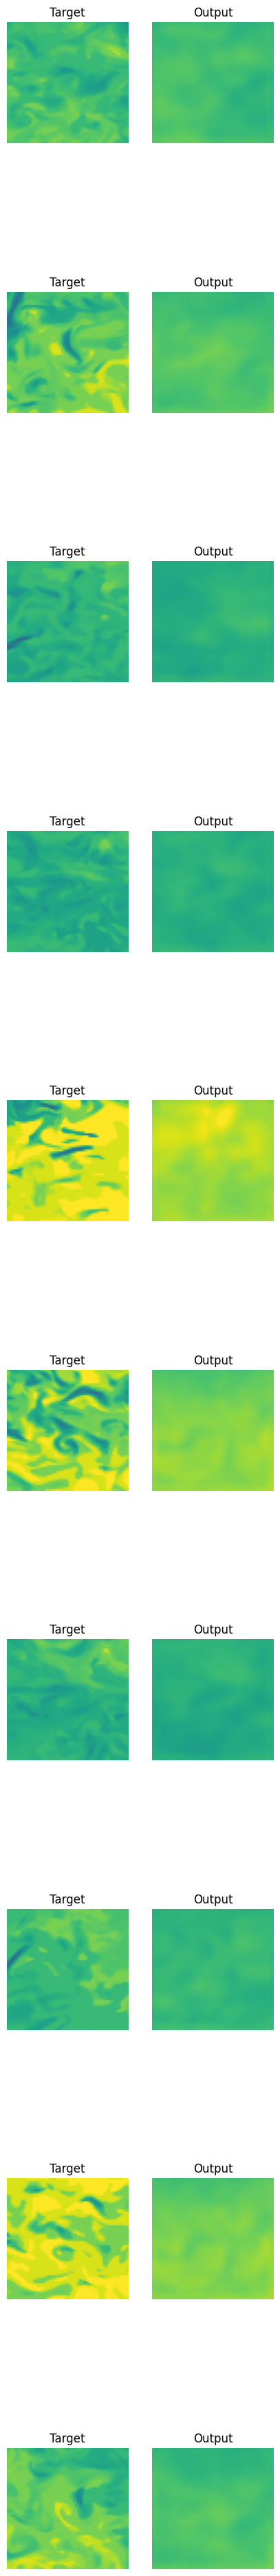

In [ ]:
num_samples = 10

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5*num_samples), nrows=num_samples, ncols=2)

for i, batch in enumerate(test_dataloader):
    inputs, targets = batch
    inputs, targets = inputs.to(device), targets.to(device)

    with torch.no_grad():
        outputs = model(inputs)

    targets_np = targets.cpu().numpy()
    outputs_np = outputs.cpu().numpy()

    y, fake_y = dataset.std_label*targets_np+dataset.mean_label, dataset.std_label*outputs_np+dataset.mean_label

    ax[i, 0].imshow(y[0, 0], cmap='viridis', vmin=0, vmax=90)
    ax[i, 0].set_title("Target")
    ax[i, 0].axis('off')

    ax[i, 1].imshow(fake_y[0, 0], cmap='viridis', vmin=0, vmax=90)
    ax[i, 1].set_title("Output")
    ax[i, 1].axis('off')

    if i == num_samples - 1:
        break


/tmp/ipykernel_874775/1317763320.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y, fake_y = dataset.std_label*targets_np+dataset.mean_label, dataset.std_label*outputs_np+dataset.mean_label


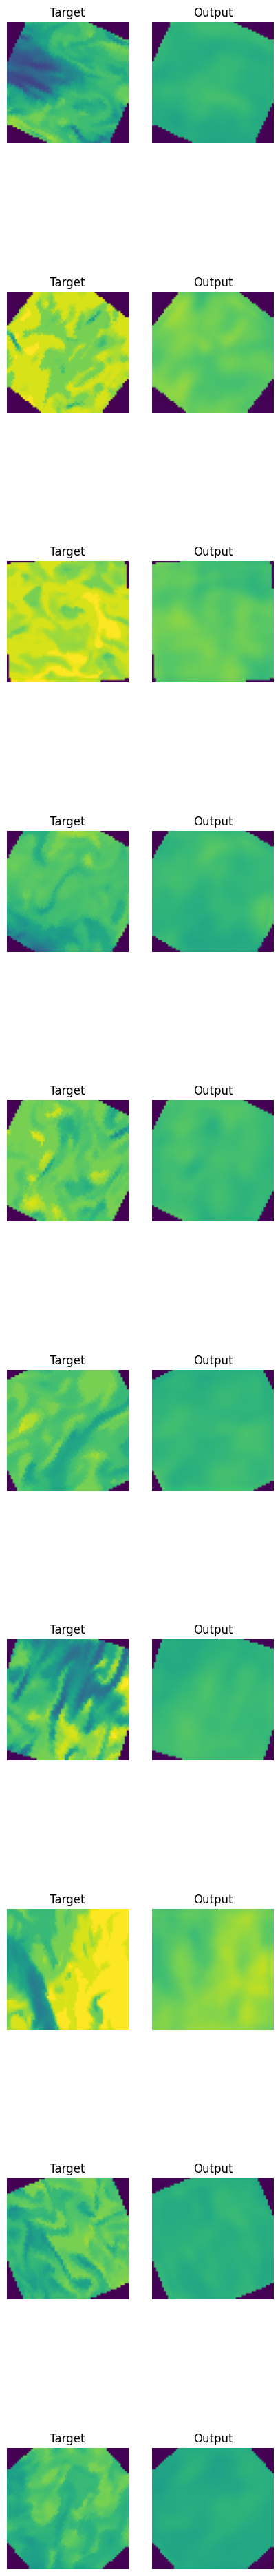

In [ ]:
train_dataloader_inference = DataLoader(Subset(dataset, train_indices), batch_size=1, shuffle=True)

fig, ax = plt.subplots(figsize=(5, 5*num_samples), nrows=num_samples, ncols=2)

for i, batch in enumerate(train_dataloader_inference):
    inputs, targets = batch
    inputs, targets = inputs.to(device), targets.to(device)

    with torch.no_grad():
        outputs = model(inputs)

    targets_np = targets.cpu().numpy()
    outputs_np = outputs.cpu().numpy()

    y, fake_y = dataset.std_label*targets_np+dataset.mean_label, dataset.std_label*outputs_np+dataset.mean_label

    ax[i, 0].imshow(y[0, 0], cmap='viridis', vmin=0, vmax=90)
    ax[i, 0].set_title("Target")
    ax[i, 0].axis('off')

    ax[i, 1].imshow(fake_y[0, 0], cmap='viridis', vmin=0, vmax=90)
    ax[i, 1].set_title("Output")
    ax[i, 1].axis('off')

    if i == num_samples - 1:
        break

### DepthAnything

#### load model

In [8]:
from depth_anything_v2.dpt import DepthAnythingV2

model = DepthAnythingV2(in_channels=5).to(device)

xFormers not available
xFormers not available


In [9]:
model

DepthAnythingV2(
  (pretrained): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(5, 1024, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-23): 24 x NestedTensorBlock(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (drop): Dropout(p=0.0, inplace=Fal

In [10]:
dataset[0][0].shape, dataset[0][1].shape

(torch.Size([5, 70, 70]), torch.Size([70, 70]))

In [11]:
X = dataset[0][0].unsqueeze(0).to(device)
y = dataset[0][1].unsqueeze(0).to(device)

print(X.shape, y.shape)

model.eval()

model(X).shape

torch.Size([1, 5, 70, 70]) torch.Size([1, 70, 70])


torch.Size([1, 70, 70])

In [12]:
X = torch.randn(20, 5, 70, 70).to(device)
y = torch.randn(20, 1, 70, 70).to(device)

model(X).shape

torch.Size([20, 70, 70])

In [13]:
depth_anything_dir = Path(PROJECT_ROOT) / "models" / f"depth_anything_{season}_{relative_filepath.split('/')[-1].split('.')[0]}_"

#### Delete dir

In [14]:
import os

if not depth_anything_dir.exists():
    depth_anything_dir.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {depth_anything_dir}")
for filename in os.listdir(depth_anything_dir):
    file_path = os.path.join(depth_anything_dir, filename)

    # Check if it is a file (not a subdirectory)
    if os.path.isfile(file_path):
        os.remove(file_path)  # Remove the file
        print(f"Deleted file: {filename}")

os.rmdir(depth_anything_dir)

Deleted file: best_model.pth
Deleted file: best_model_full.pth
Deleted file: best_val_loss.pth
Deleted file: optimizer.pth


#### load dir

In [15]:
# Create directory for saving models
if not depth_anything_dir.exists():
    depth_anything_dir.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {depth_anything_dir}")

# Function to save models
def save_depth_anything_models(best_val_loss, optimizer, dir):
    torch.save(model.state_dict(), dir / "best_model.pth")
    torch.save(optimizer.state_dict(), dir / "optimizer.pth")
    torch.save(model, dir / "best_model_full.pth")
    torch.save(best_val_loss, dir / "best_val_loss.pth")

# Function to load models
def load_depth_anything_models(dir, optimizer):
    if optimizer:
        optimizer.load_state_dict(torch.load(dir / "optimizer.pth"))
    best_val_loss = torch.load(dir / "best_val_loss.pth")
    loaded_model = torch.load(dir / "best_model_full.pth", weights_only=False)
    loaded_model.to(device)
    return best_val_loss, loaded_model

Created directory: /mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/models/depth_anything_winter_WaterOnlyDailyExtendedSeasonalitySmall_


In [16]:
backbone_params = list(model.pretrained.parameters())
head_params = list(model.depth_head.parameters())

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},  # Lower LR for pretrained
    {'params': head_params, 'lr': 1e-4}       # Higher LR for head
])

from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)



In [17]:
for name, param in model.pretrained.named_parameters():
    print(f"{name}: requires_grad = {param.requires_grad}")

cls_token: requires_grad = True
pos_embed: requires_grad = True
mask_token: requires_grad = True
patch_embed.proj.weight: requires_grad = True
patch_embed.proj.bias: requires_grad = True
blocks.0.norm1.weight: requires_grad = True
blocks.0.norm1.bias: requires_grad = True
blocks.0.attn.qkv.weight: requires_grad = True
blocks.0.attn.qkv.bias: requires_grad = True
blocks.0.attn.proj.weight: requires_grad = True
blocks.0.attn.proj.bias: requires_grad = True
blocks.0.ls1.gamma: requires_grad = True
blocks.0.norm2.weight: requires_grad = True
blocks.0.norm2.bias: requires_grad = True
blocks.0.mlp.fc1.weight: requires_grad = True
blocks.0.mlp.fc1.bias: requires_grad = True
blocks.0.mlp.fc2.weight: requires_grad = True
blocks.0.mlp.fc2.bias: requires_grad = True
blocks.0.ls2.gamma: requires_grad = True
blocks.1.norm1.weight: requires_grad = True
blocks.1.norm1.bias: requires_grad = True
blocks.1.attn.qkv.weight: requires_grad = True
blocks.1.attn.qkv.bias: requires_grad = True
blocks.1.attn.p

In [18]:
for param in model.parameters():
    param.requires_grad = True

In [19]:
# Initialize best validation loss
best_val_loss = float('inf')
if depth_anything_dir.exists() and (depth_anything_dir / "best_val_loss.pth").exists():
    best_val_loss, model = load_depth_anything_models(depth_anything_dir, optimizer)
else:
    save_depth_anything_models(best_val_loss, optimizer, depth_anything_dir)

In [20]:
def check_gradients(model, loss):
    """Check if gradients are flowing properly"""
    loss.backward()
    
    total_norm = 0
    param_count = 0
    zero_grad_count = 0
    
    for name, param in model.named_parameters():
        if param.grad is not None:
            param_norm = param.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
            param_count += 1
            
            if param_norm.item() < 1e-7:
                zero_grad_count += 1
                print(f"Very small gradient: {name}: {param_norm.item()}")
        else:
            print(f"No gradient: {name}")
    
    total_norm = total_norm ** (1. / 2)
    print(f"Total gradient norm: {total_norm}")
    print(f"Zero/tiny gradients: {zero_grad_count}/{param_count}")
    
    return total_norm

In [21]:
# Initialize weights using Kaiming normal
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(init_weights)

DepthAnythingV2(
  (pretrained): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(8, 1024, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-23): 24 x NestedTensorBlock(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (drop): Dropout(p=0.0, inplace=Fal

#### train

In [22]:
# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    
    for i, batch in enumerate(train_dataloader):
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs).unsqueeze(1)  
        loss = F.mse_loss(outputs, targets)

        # check_gradients(model, loss)  
        loss.backward()
        optimizer.step()
                
        train_loss = loss.item()
        if i % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch Loss: {train_loss:.4f}, Batch: {i+1}/{len(train_dataloader)}")
        
        epoch_train_loss += train_loss
    
    avg_train_loss = epoch_train_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss}")
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs).unsqueeze(1)
            loss = F.mse_loss(outputs, targets)
            val_loss += loss.item()
    
    val_loss /= len(val_dataloader)
    scheduler.step(val_loss)  

    print(f"Epoch [{epoch+1}/{num_epochs}], Val Loss: {val_loss}")
    
    # Save model if validation loss improves
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_depth_anything_models(best_val_loss, optimizer, depth_anything_dir)
        print(f"New best validation loss: {best_val_loss}, model saved.")
    
    print("\n")

Epoch [1/5], Batch Loss: 327.0471, Batch: 1/260
Epoch [1/5], Batch Loss: 0.5685, Batch: 11/260
Epoch [1/5], Batch Loss: 0.6302, Batch: 21/260
Epoch [1/5], Batch Loss: 0.6950, Batch: 31/260
Epoch [1/5], Batch Loss: 0.6115, Batch: 41/260
Epoch [1/5], Batch Loss: 0.6211, Batch: 51/260
Epoch [1/5], Batch Loss: 0.5807, Batch: 61/260
Epoch [1/5], Batch Loss: 0.4046, Batch: 71/260
Epoch [1/5], Batch Loss: 0.5519, Batch: 81/260
Epoch [1/5], Batch Loss: 0.6334, Batch: 91/260
Epoch [1/5], Batch Loss: 0.5356, Batch: 101/260
Epoch [1/5], Batch Loss: 0.3883, Batch: 111/260
Epoch [1/5], Batch Loss: 0.4599, Batch: 121/260
Epoch [1/5], Batch Loss: 0.7649, Batch: 131/260
Epoch [1/5], Batch Loss: 0.4906, Batch: 141/260
Epoch [1/5], Batch Loss: 0.6499, Batch: 151/260
Epoch [1/5], Batch Loss: 0.7844, Batch: 161/260
Epoch [1/5], Batch Loss: 0.5874, Batch: 171/260
Epoch [1/5], Batch Loss: 0.6653, Batch: 181/260
Epoch [1/5], Batch Loss: 0.7895, Batch: 191/260
Epoch [1/5], Batch Loss: 0.7024, Batch: 201/260
E

In [24]:
next(iter(train_dataloader))

[tensor([[[[-2.4450e-03, -2.4637e-03, -2.4694e-03,  ..., -2.1271e-03,
            -2.1271e-03, -2.1271e-03],
           [-2.4610e-03, -2.4674e-03, -2.4694e-03,  ..., -2.1271e-03,
            -2.1271e-03, -2.1271e-03],
           [-2.4799e-03, -2.4799e-03, -2.4735e-03,  ..., -2.1271e-03,
            -2.1296e-03, -2.1376e-03],
           ...,
           [-1.7464e-03, -1.7464e-03, -1.7549e-03,  ..., -1.0286e-03,
            -1.0526e-03, -1.0339e-03],
           [-1.7359e-03, -1.7359e-03, -1.7457e-03,  ..., -9.7205e-04,
            -9.8412e-04, -9.2699e-04],
           [-1.7359e-03, -1.7359e-03, -1.7359e-03,  ..., -9.2385e-04,
            -9.1319e-04, -7.8239e-04]],
 
          [[ 1.0427e+00,  1.0427e+00,  1.0426e+00,  ...,  1.0456e+00,
             1.0459e+00,  1.0463e+00],
           [ 1.0433e+00,  1.0434e+00,  1.0434e+00,  ...,  1.0458e+00,
             1.0461e+00,  1.0464e+00],
           [ 1.0443e+00,  1.0444e+00,  1.0444e+00,  ...,  1.0462e+00,
             1.0464e+00,  1.0466e+00],


#### functionality check

In [8]:
import time
dir = Path(PROJECT_ROOT) / "models" / f"full_DA_{time.strftime('%Y%m%d_%H%M%S')}_{relative_filepath.split('/')[-1].split('.')[0]}_"

In [9]:
X, y= dataset[5]
X, y = X.unsqueeze(0), y.unsqueeze(0)
# X, y = next(iter(train_dataloader))
X, y = X.to(device), y.to(device)
X.shape, y.shape

(torch.Size([1, 5, 70, 70]), torch.Size([1, 70, 70]))

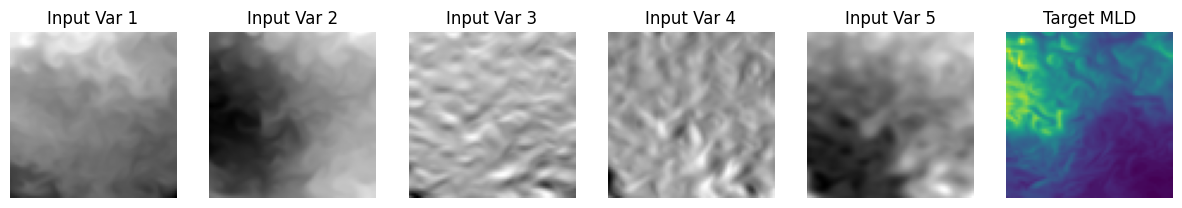

In [10]:
fig, ax = plt.subplots(figsize=(15*X.shape[0], 15*(X.shape[1]+1)), nrows=X.shape[0], ncols=X.shape[1]+1)
# ensure ax is at least 2D
ax = np.atleast_2d(ax)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        ax[i, j].imshow(X[i, j].cpu().numpy(), cmap='gray')
        ax[i, j].axis('off')
        ax[i, j].set_title(f"Input Var {j+1}")
    ax[i, -1].imshow(y[i].cpu().numpy(), cmap='viridis')
    ax[i, -1].set_title("Target MLD")
    ax[i, -1].axis('off')

In [18]:
backbone_params = list(model.pretrained.parameters())
head_params = list(model.depth_head.parameters())

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-6},  # Lower LR for pretrained
    {'params': head_params, 'lr': 1e-4}       # Higher LR for head
])


scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [19]:
best_val_loss = float('inf')
if not dir.exists():
    best_val_loss = float('inf')
    dir.mkdir(parents=True, exist_ok=True)
else:
    best_val_loss = torch.load(dir / "best_val_loss.pth")
    model.load_state_dict(torch.load(dir / "best_model.pth"))

In [25]:
for i in range(1000):
    y_predict = model(X)
    loss = F.l1_loss(y_predict, y)
    loss.backward()
    optimizer.step()
    scheduler.step(loss)
    print(f"Iteration {i+1}, Loss: {loss.item()}")

    # Save model if validation loss improves
    if i % 5 == 0:  
        if loss.item() < best_val_loss:
            best_val_loss = loss.item()
            torch.save(model.state_dict(), dir / "best_model.pth")
            torch.save(best_val_loss, dir / "best_val_loss.pth")

Iteration 1, Loss: 0.1575772762298584
Iteration 2, Loss: 0.15756040811538696
Iteration 3, Loss: 0.1575465351343155
Iteration 4, Loss: 0.1575317531824112
Iteration 5, Loss: 0.1575189232826233
Iteration 6, Loss: 0.157504141330719
Iteration 7, Loss: 0.15749101340770721
Iteration 8, Loss: 0.15747953951358795
Iteration 9, Loss: 0.1574655920267105
Iteration 10, Loss: 0.157454252243042
Iteration 11, Loss: 0.15744233131408691
Iteration 12, Loss: 0.15743191540241241
Iteration 13, Loss: 0.15742266178131104
Iteration 14, Loss: 0.15741319954395294
Iteration 15, Loss: 0.15740492939949036
Iteration 16, Loss: 0.15739519894123077
Iteration 17, Loss: 0.15738500654697418
Iteration 18, Loss: 0.15737834572792053
Iteration 19, Loss: 0.15736813843250275
Iteration 20, Loss: 0.15736225247383118
Iteration 21, Loss: 0.1573544591665268
Iteration 22, Loss: 0.1573488861322403
Iteration 23, Loss: 0.157339945435524
Iteration 24, Loss: 0.15733599662780762
Iteration 25, Loss: 0.15733425319194794
Iteration 26, Loss: 0.

KeyboardInterrupt: 

In [22]:
model.load_state_dict(torch.load(dir / "best_model.pth"))

<All keys matched successfully>

torch.Size([1, 1, 70, 70]) torch.Size([1, 70, 70])


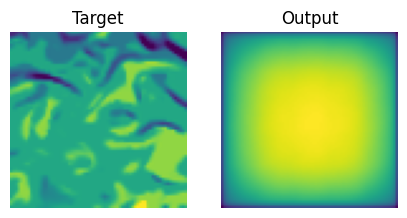

In [24]:
import matplotlib.pyplot as plt

model.eval()

y_predict = model(X).unsqueeze(1)
print(y_predict.shape, y.shape)



fig, ax = plt.subplots(figsize=(5, 20), nrows=y.shape[0], ncols=2)
ax = np.atleast_2d(ax)
for i in range(y.shape[0]):
    ax[i, 0].imshow(y[i].cpu().numpy(), cmap='viridis', vmin=0, vmax=1)
    ax[i, 0].set_title("Target")
    ax[i, 0].axis('off')
    ax[i, 1].imshow(y_predict[i, 0].detach().cpu().numpy(), cmap='viridis')
    ax[i, 1].set_title("Output")
    ax[i, 1].axis('off')

### Back to Basics

In [11]:
from models.UNetfullimageoutput import UNet
from models.UNET_regressionSE_full import UNetRegressionSEFull
from models.simple_CNN import PixelWiseRegressor

In [12]:
# model = UNet(in_channels=8, out_channels=1, base_channels=64).to(device)
model = DA_CNN_FULL(in_channels=5, out_channels=1, first_layer_filters=256).to(device)

In [10]:
model = PixelWiseRegressor(in_channels=6, out_channels=1).to(device)
model(torch.randn(1, 6, 70, 70).to(device)).shape

torch.Size([1, 1, 70, 70])

In [11]:
class ViTWithDecoder(nn.Module):
    def __init__(self, img_size=70, patch_size=10, in_chans=6, dim=128, depth=4, num_heads=4, out_chans=1):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2

        self.patch_embed = nn.Conv2d(in_chans, dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=num_heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Decoder: learn spatial upsampling
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(dim, 128, kernel_size=2, stride=2),  # 7x7 → 14x14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),   # 14x14 → 28x28
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_chans, kernel_size=3, padding=1),     # 28x28 → 28x28
            nn.Upsample(size=(img_size, img_size), mode='bilinear', align_corners=False)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.patch_embed(x)  # (B, dim, H/patch, W/patch)
        Hp, Wp = x.shape[2], x.shape[3]

        x = x.flatten(2).transpose(1, 2)  # (B, N, dim)
        x = x + self.pos_embed
        x = self.encoder(x)              # (B, N, dim)

        x = x.transpose(1, 2).reshape(B, -1, Hp, Wp)  # (B, dim, H/patch, W/patch)
        x = self.decoder(x)  # (B, 1, H, W)
        return x


In [12]:
model = ViTWithDecoder(img_size=70, patch_size=5, in_chans=6, dim=128, depth=4, num_heads=4).to(device)
model(torch.randn(1, 6, 70, 70).to(device)).shape

torch.Size([1, 1, 70, 70])

In [13]:
# from models.swin_transformer_unet_skip_expand_decoder_sys.py

In [51]:
model = UNetRegressionSEFull(in_channels=5, out_channels=1, base_filters=128, reduction=2).to(device)

In [193]:
model = ResNetImageToImage(in_channels=5, out_channels=1, n_blocks=5, base_channels=256, norm='in', final_activation=None)


In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-6)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [14]:
model.to(device)

DA_CNN_FULL(
  (convcam1): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(5, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Identity()
    )
  )
  (convcam2): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Identity()
    )
  )
  (cam): ChannelAttentionModule(
    (flatten): Flatten(start_dim=2, end_dim=-1)
    (softmax): Softmax(dim=2)
  )
  (convcam3): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Identity()
    )
  )
  (convpam1): ConvReluBlock(
    (block): Seque

In [ ]:
dir = Path(PROJECT_ROOT) / "FULL" / f"full_DA_{time.strftime('%Y%m%d_%H%M%S')}_{season}_{relative_filepath.split('/')[-1].split('.')[0]}_"

In [16]:
best_val_loss = float('inf')
if not dir.exists():
    best_val_loss = float('inf')
    dir.mkdir(parents=True, exist_ok=True)
else:
    best_val_loss = torch.load(dir / "best_val_loss.pth")
    model.load_state_dict(torch.load(dir / "best_model.pth"))

In [17]:
print(model(X).shape, y.shape)

torch.Size([1, 1, 70, 70]) torch.Size([1, 70, 70])


In [18]:
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure

ssim = StructuralSimilarityIndexMeasure(data_range=2.0)
img1 = torch.rand(1, 1, 128, 128)
img2 = torch.rand(1, 1, 128, 128)

score = ssim(img1, img2)
print(score.item())

0.024870531633496284


In [19]:
model = model.to(device)
X = X.to(device)
y = y.to(device)

ssim = ssim.to(device)

In [ ]:
for i in range(1000):
    y_predict = model(X)
    # loss = F.mse_loss(y_predict.squeeze(0).squeeze(0), y.squeeze(0))
    loss = 1- ssim(y_predict, y.unsqueeze(0))

    loss.backward()
    optimizer.step()
    # scheduler.step(loss)
    print(f"Iteration {i+1}, Loss: {loss.item()}")
    if loss.item() < best_val_loss:
        best_val_loss = loss.item()
        torch.save(model.state_dict(), dir / "best_model.pth")
        torch.save(best_val_loss, dir / "best_val_loss.pth")

Iteration 1, Loss: 1.3614747524261475
Iteration 2, Loss: 1.3300737142562866
Iteration 3, Loss: 1.301988959312439
Iteration 4, Loss: 1.2773382663726807
Iteration 5, Loss: 1.2557170391082764
Iteration 6, Loss: 1.2373831272125244
Iteration 7, Loss: 1.222069501876831
Iteration 8, Loss: 1.2090463638305664
Iteration 9, Loss: 1.1977784633636475
Iteration 10, Loss: 1.1879392862319946
Iteration 11, Loss: 1.1791526079177856
Iteration 12, Loss: 1.170988917350769
Iteration 13, Loss: 1.163155198097229
Iteration 14, Loss: 1.1554733514785767
Iteration 15, Loss: 1.1477826833724976
Iteration 16, Loss: 1.140051007270813
Iteration 17, Loss: 1.1321909427642822
Iteration 18, Loss: 1.124289631843567
Iteration 19, Loss: 1.1163082122802734
Iteration 20, Loss: 1.1081936359405518
Iteration 21, Loss: 1.0999538898468018
Iteration 22, Loss: 1.0916059017181396
Iteration 23, Loss: 1.0831550359725952
Iteration 24, Loss: 1.0746188163757324
Iteration 25, Loss: 1.0660456418991089
Iteration 26, Loss: 1.0574533939361572
I

In [ ]:
model.load_state_dict(torch.load(dir / "best_model.pth"))

RuntimeError: PytorchStreamReader failed locating file data/16: file not found

torch.Size([1, 1, 70, 70]) torch.Size([1, 70, 70])


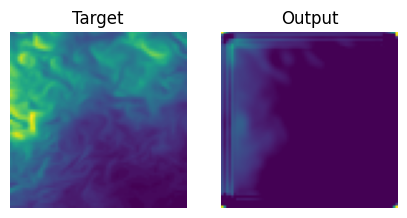

In [ ]:
import matplotlib.pyplot as plt

model.eval()

y_predict = model(X)
v_max = max(y_predict.max().item(), y.max().item())
print(y_predict.shape, y.shape)

v_min = y.min().item()
v_max = y.max().item()


fig, ax = plt.subplots(figsize=(5, 20), nrows=y.shape[0], ncols=2)
ax = np.atleast_2d(ax)
for i in range(y.shape[0]):
    ax[i, 0].imshow(y[i].cpu().numpy(), vmin=v_min, vmax=v_max, cmap='viridis')
    ax[i, 0].set_title("Target")
    ax[i, 0].axis('off')
    ax[i, 1].imshow(y_predict[i, 0].detach().cpu().numpy(), vmin=v_min, vmax=v_max, cmap='viridis')
    ax[i, 1].set_title("Output")
    ax[i, 1].axis('off')

In [ ]:
from combo_new_mod import plot_grids, general_plot
mld_labels, mld_preds, test_temps = plot_grids(test_dataloader, model, device)


ModuleNotFoundError: No module named 'combo_new_mod'

In [ ]:
total_mae, total_rmse, r2 = general_plot(mld_labels, mld_preds, test_temps, season, model.name(), dir)
